In [1]:
import os, sys, glob
# from abc import ABCMeta, abstractmethod, abstractproperty
import abc
from enum import Enum
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
import json

import space_phot
from astropy.io import fits
from jwst.associations import asn_from_list
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base
from jwst.pipeline import Image3Pipeline
from jwst.skymatch import SkyMatchStep
from jwst.datamodels import ModelLibrary

# Hack - I moved this into a local notebooks dir...
sys.path.append("/Users/mgriggio/diffpype/src/jwst_diff")
from image1overf import sub1fimaging

sys.path.append("/Users/mgriggio/diffpype/src/workflow_manager")
from data_repository import RepositoryFactory 
from data_utils import DataUtils
from visualization import Visualizer


from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

from mocpy import MOC
from mocpy import WCS as mocWCS
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.time import Time
import numpy as np

import pandas as pd
import mysql.connector

import mysql.connector
from mysql.connector import Error
from mysql.connector.pooling import MySQLConnectionPool
from pprint import pprint
import math

import pdb

import healpy as hp




The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


# Simulate data access layer

In [8]:
jwst_sw_linear_size = 1.054 # arcmin on a side
jwst_sw_module_area_sq_deg = (2040*0.031/3600)**2
print("\nArea per JWST SW module: %s deg^2" % jwst_sw_module_area_sq_deg)

JWST_MODULE_NSIDE = 2097152
power_of_two = int(np.log10(JWST_MODULE_NSIDE)/np.log10(2))
print("Max Depth: %s" % power_of_two)
jwst_hp_area_sq_deg = hp.nside2pixarea(nside=JWST_MODULE_NSIDE, degrees=True)
print("Area per JWST_MODULE_NSIDE %s pixel: %s deg^2" % (JWST_MODULE_NSIDE, jwst_hp_area_sq_deg))

hp_per_jwst = jwst_sw_module_area_sq_deg/jwst_hp_area_sq_deg
print("JWST_MODULE_NSIDE pixels per native JWST SW module: %s" % hp_per_jwst)


GLOBAL_CONFIG = {
    "mysql_config": {
        'host': '127.0.0.1',
        'port':'3307',
        'database': 'diffpype4',
        'user': 'dev',
        'password': 'devpass'
    },
    "filesystem_config": {
        "mast_proxy":"/astro/armin/data/mgriggio/hollis/MAST_PROXY/",
        "base_dir":"/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline"
    },
    "moc_settings":{
        "moc_max_depth":power_of_two
    }

}

repo_type = "mysql"
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)

# Retrieve images hits the db to get images. This will come from a MAST query in the future
# image_df = data_repo.retrieve_images()
# print(len(image_df))


project_name = 'HOLLIS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']

data_repo.set_project_context(project_df)


Area per JWST SW module: 0.0003085877777777778 deg^2
Max Depth: 21
Area per JWST_MODULE_NSIDE 2097152 pixel: 7.816531185164738e-10 deg^2
JWST_MODULE_NSIDE pixels per native JWST SW module: 394788.6478895614
Connection pool 'mypool' initialized with size 5.
Returning Project: HOLLIS
5
Returning Project: HOLLIS
   id    name
0   5  HOLLIS
Project directories created.


In [9]:
# Execute MAST query (proxy) to get raw image files into the raw image dir
raw_images = data_repo.get_images_from_MAST()
# data_repo.save_images(raw_images)

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_17201_00002_nrcb2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_17201_00002_nrcb2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001005_02101_00001_nrcb3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001005_02101_00001_nrcb3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001003_19201_00002_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001003_19201_00002_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_17201_00001_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_17201_00001_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_11201_00002_nrca3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_11201_00002_nrca3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001003_13201_00003_nrcb3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001003_13201_00003_nrcb3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_19201_00001_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_19201_00001_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001004_02101_00001_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001004_02101_00001_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001003_07101_00002_nrcb3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001003_07101_00002_nrcb3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001008_03103_00004_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001008_03103_00004_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw04452044001_02101_00002_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw04452044001_02101_00002_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001004_07201_00003_nrcb2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001004_07201_00003_nrcb2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_17201_00002_nrca3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_17201_00002_nrca3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_03201_00002_nrcalong_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_03201_00002_nrcalong_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001002_03201_00002_nrcblong_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001002_03201_00002_nrcblong_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_13201_00001_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_13201_00001_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diff

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001001_05101_00001_nrcb4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001001_05101_00001_nrcb4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001008_03101_00004_nrcb2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001008_03101_00004_nrcb2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_07201_00002_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_07201_00002_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_19201_00001_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_19201_00001_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

...

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001005_04101_00003_nrcb3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001005_04101_00003_nrcb3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001004_15201_00001_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001004_15201_00001_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001005_02101_00001_nrca3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001005_02101_00001_nrca3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_15201_00002_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_15201_00002_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001004_19201_00002_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001004_19201_00002_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001002_07101_00002_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001002_07101_00002_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001003_04101_00004_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001003_04101_00004_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001001_04101_00002_nrcb1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001001_04101_00002_nrcb1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw06630026001_02101_00003_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw06630026001_02101_00003_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_07201_00003_nrcb4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_07201_00003_nrcb4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001006_04101_00001_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001006_04101_00001_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001001_02101_00003_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001001_02101_00003_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001003_02101_00002_nrcb4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001003_02101_00002_nrcb4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001003_11201_00002_nrca3_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001003_11201_00002_nrca3_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001001_07201_00001_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001001_07201_00001_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001005_15201_00002_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001005_15201_00002_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001005_04101_00003_nrca4_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001005_04101_00003_nrca4_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw03215001002_15201_00002_nrca1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw03215001002_15201_00002_nrca1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw01895001004_04101_00002_nrcb1_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw01895001004_04101_00002_nrcb1_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/working_pipeline/HOLLIS/rawimage/jw06630026001_02101_00002_nrca2_cal.fits' -> '/astro/armin/data/mgriggio/hollis/MAST_PROXY//jw06630026001_02101_00002_nrca2_cal.fits'
Created symlink: '/astro/armin/data/mgriggio/hollis/diffpype_root/wo

In [10]:
# Filter which of these files we wish to enter the pipeline -- e.g., remove everything with exp_time < 100 seconds, etc.
IMAGE_WHERE = [
    'exp_time > 10.0',
    'id > 0'
]

# Save images to Lvl2Cal table
lvl2_df = data_repo.import_images_to_lvl2cals(IMAGE_WHERE)

# Or, if they already exist:
# lvl2_df = data_repo.retrieve_lvl2_cals()

pprint(len(lvl2_df))



Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.
1519


# RELOAD

In [11]:
from concurrent.futures import ProcessPoolExecutor, as_completed
#Helpful re-load 
import importlib
import visualization
import data_repository
import data_utils

importlib.reload(visualization)
importlib.reload(data_repository)
importlib.reload(data_utils)

# viz = visualization.Visualizer("/Users/dcoulter/Code/notebooks/diffpype/images/")
data_repo = RepositoryFactory.get_repository(repo_type, GLOBAL_CONFIG)
project_name = 'HOLLIS'
project_df = data_repo.save_project(project_name)
pprint(project_df)
project_id = project_df.loc[0, 'id']
data_repo.set_project_context(project_df)

# lvl2_df = data_repo.retrieve_lvl2_cals()
# project_df = data_repo.retrieve_project(project_name)
# project_id = project_df.loc[0, 'id']
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# 
viz = visualization.Visualizer("/Users/mgriggio/Desktop")

Connection pool 'mypool' initialized with size 5.
Returning Project: HOLLIS
Record already exists! Returning existing...
   id    name
0   5  HOLLIS
Project directories created.


0.0375
0.0375
All Sky statistics
	Num of dec strips: 4799
	Northern most dec: 89.94372222222223
	Southern most dec: -89.98125
	Eastern most ra: 359.94372222121973
	Western most ra: 0.01875000100250066
	Num of ra tiles in northern most dec slice: 10
	Num of ra tiles at celestial equator: 9599
Constructing grid of coordinates...
Number of coords near (53.1209, -27.8088) within a 0.2782 deg radius: 174


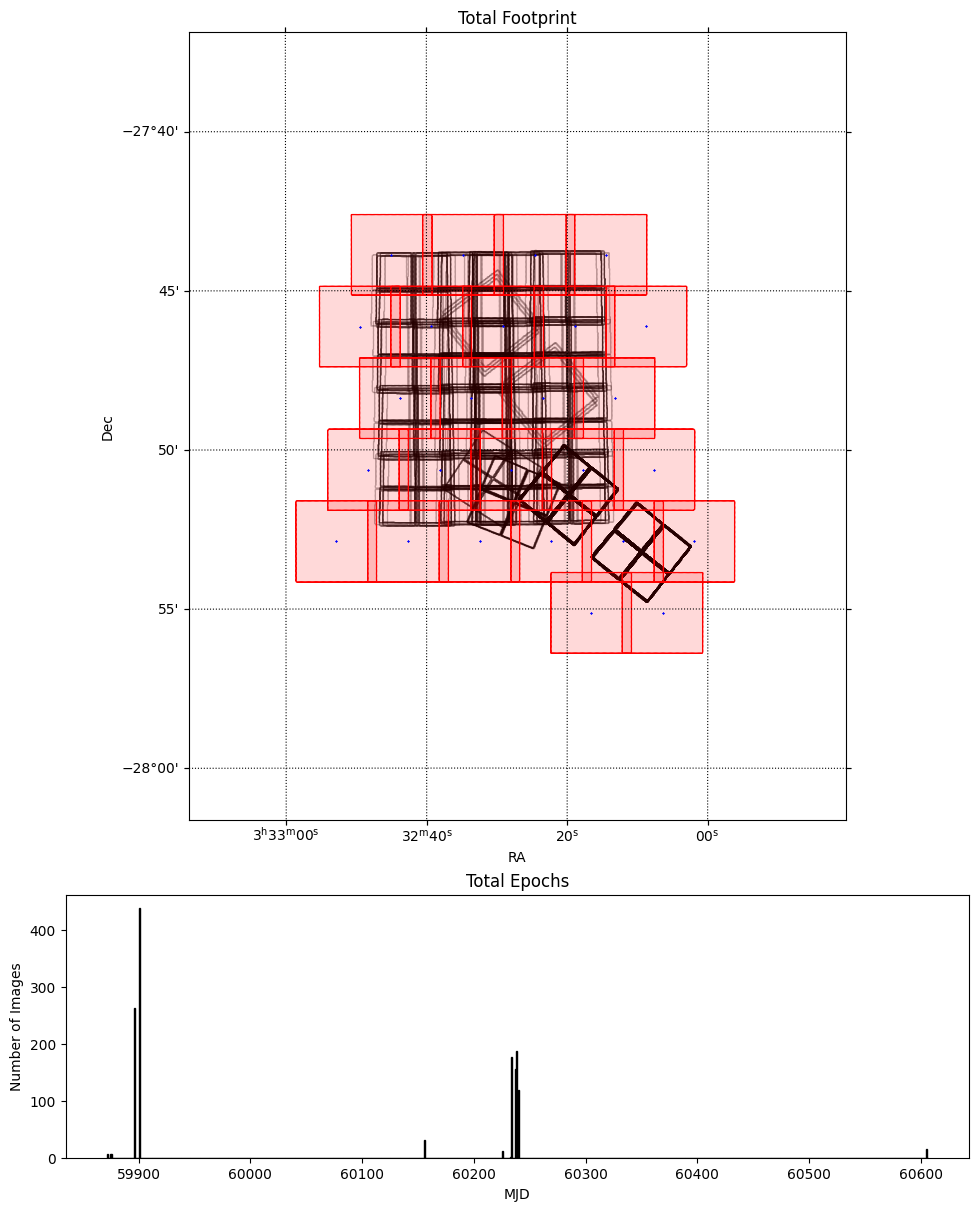

In [17]:
unioned_image_moc = data_utils.DataUtils.Get_Unioned_MOC(lvl2_df.moc)
tile_dataframe = data_utils.DataUtils.GenerateSkyTiles(project_id=project_id,
                                            tile_side_length_arc_min=2.5, 
                                            overlap_in_arc_min=0.25, 
                                            moc_to_tile=unioned_image_moc)
# tile_dataframe = data_repo.retrieve_tiles(project_name)

unioned_tile_moc = data_utils.DataUtils.Get_Unioned_MOC(tile_dataframe.moc)

covered_area = unioned_tile_moc.sky_fraction*41253
fov_proxy = 1.75*np.sqrt(covered_area) # add a fudge factor since areas aren't circles...
barycenter = unioned_tile_moc.barycenter()

viz = visualization.Visualizer("/Users/mgriggio/Desktop")
viz.plot_footprint_and_epochs(moc_list=lvl2_df.moc, 
                              epoch_list=lvl2_df.mjd_avg, 
                              footprint_title="Total Footprint", 
                              hist_title="Total Epochs", 
                              central_coord=barycenter, 
                              fov_degrees=fov_proxy, 
                              tile_df=tile_dataframe)

In [20]:
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name, clobber=True) 
# tiles_df = data_repo.save_tiles(tile_dataframe, project_name)
# pprint(len(tiles_df))

tiles_df = data_repo.retrieve_tiles(project_name)
print(tiles_df['name'].to_string(index=False))

Returning Project: HOLLIS
Returning tiles for Project: HOLLIS
 Tile_1
 Tile_2
 Tile_3
 Tile_4
 Tile_5
 Tile_6
 Tile_7
 Tile_8
 Tile_9
Tile_10
Tile_11
Tile_12
Tile_13
Tile_14
Tile_15
Tile_16
Tile_17
Tile_18
Tile_19
Tile_20
Tile_21
Tile_22
Tile_23
Tile_24
Tile_25
Tile_26


In [21]:
# No safety on this -- it will just duplicate if saved again... can fix with an UPSERT specifying that the combination of lvl2 id and tile id is UNIQUE
tile_image_dict = data_repo.save_tile_image_association(project_name, tiles_df, lvl2_df)

Returning Project: HOLLIS
Returning Project: HOLLIS
Returning tile-lvl2 relation for Project: HOLLIS


In [22]:
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)

tile_ids = tile_image_dict.keys()
tile_names = [tiles_df[tiles_df["id"]==_id].name.iloc[0] for _id in tile_ids]


print("Tile ID, Tile Name, Filter Tuples")
for _id, _name in zip(tile_ids, tile_names):
    band_id_per_tile = tile_image_dict[_id].band_id.to_list()
    _tmp_b = []
    for b in band_id_per_tile:
        _tmp_b.append(b)
    uniq_b = set(_tmp_b)
    b_names = [data_repo.reverse_bands[b] for b in uniq_b]
    print(_id, _name, [(b_id, b_name) for (b_id, b_name) in zip(uniq_b, b_names)])
    
        
# pprint(type(tile_image_dict[128]))


Returning Project: HOLLIS
Returning tile-lvl2 relation for Project: HOLLIS
Tile ID, Tile Name, Filter Tuples
219 Tile_1 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
220 Tile_2 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
221 Tile_3 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
222 Tile_4 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
223 Tile_5 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
224 Tile_6 [(12, 'F210M'), (13, 'F182M')]
225 Tile_7 [(12, 'F210M'), (13, 'F182M')]
226 Tile_8 [(13, 'F182M')]
227 Tile_9 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
228 Tile_10 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
229 Tile_11 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
230 Tile_12 [(12, 'F210M'), (13, 'F182M')]
231 Tile_13 [(12, 'F210M'), (13, 'F182M')]
232 Tile_14 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
233 Tile_15 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
234 Tile_16 [(10, 'F335M'), (12, 'F210M'), (13, 'F182M')]
235 Tile_17 [(12, 'F210M'), (13, 'F182M')]
236 Tile_18 [(13, '

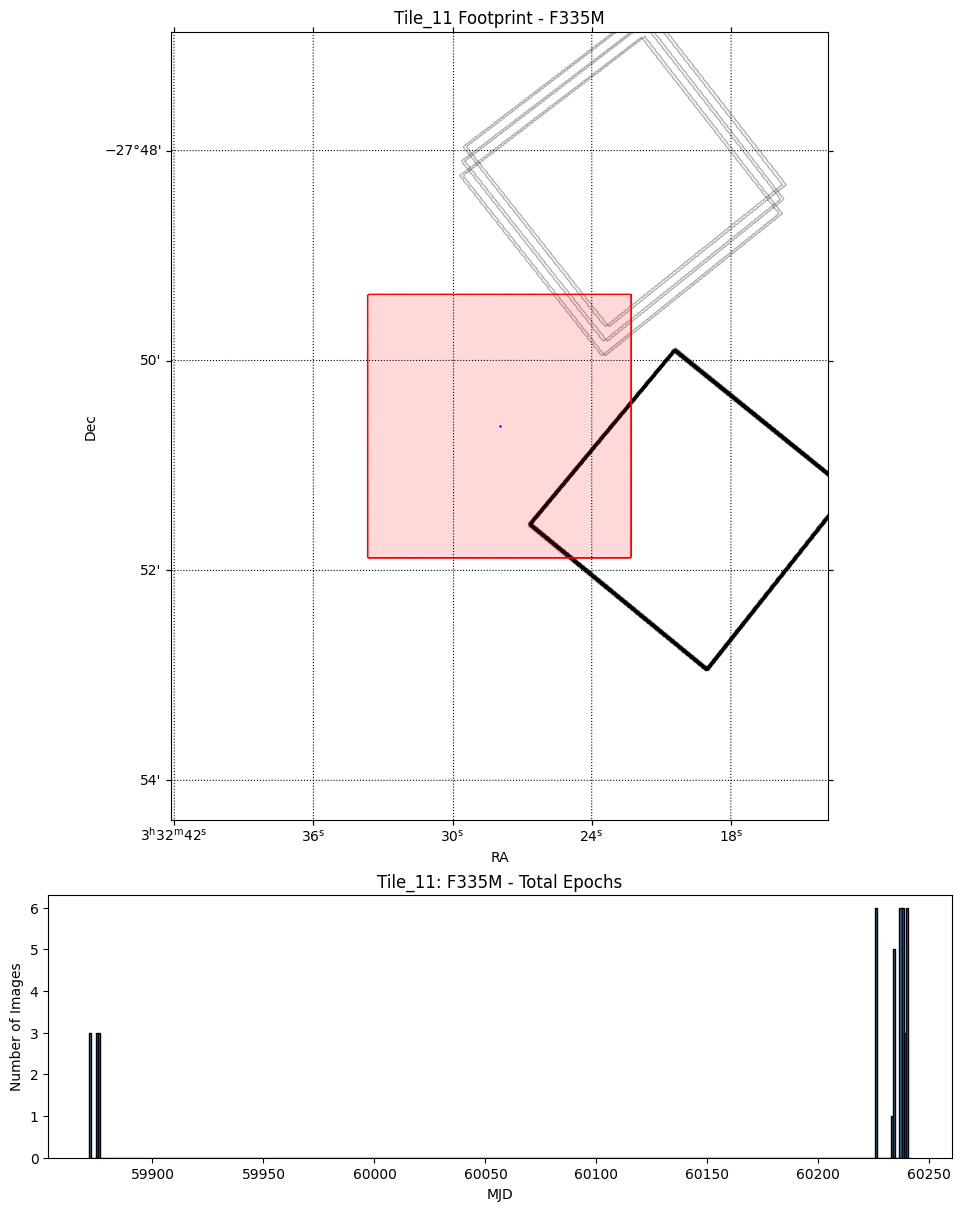

In [27]:
tile_id = 229 # Tile 1
filter_tups = [(10, 'F335M')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (8, 'F444W')]
# filter_tups = [(3, 'F200W'), (8, 'F444W')]
# filter_tups = [(8, 'F444W')]
# filter_tups = [(1, 'F115W'), (2, 'F150W'), (3, 'F200W'), (6, 'F356W'), (9, 'F090W'), (12, 'F210M'), (16, 'F444W'), (17, 'F360M')]
viz.plot_tile_contents(image_dataframe=tile_image_dict[tile_id], tile_dataframe=tiles_df, filter_tuples=filter_tups, tile_id=tile_id, fov_scale=2.5)


In [45]:
do_save = True
distance_thresh = 50

# For tile, for filter -> grab epochs from the resulting image list
for tile_id, images_in_tile in tile_image_dict.items():
    
    for _band_id in images_in_tile["band_id"].unique():        
        
        in_band_images = images_in_tile[images_in_tile["band_id"] == _band_id]
        in_band_mjds = list(in_band_images.mjd_avg)
        epochs = DataUtils.CreateEpochsFromMJDs(in_band_mjds, peak_distance_thresh=distance_thresh)
        if do_save:
            data_repo.save_tile_epochs(start_mjds=epochs[:,0], end_mjds=epochs[:,1], tile_id=tile_id, band_id=_band_id, project_id=project_id)

In [29]:
# Plot any combination of tile and band
_tile_id = 229
_tile_filter_tuple = (10, 'F335M')
# _tile_id = 17
# _tile_filter_tuple = (1, 'F115W')
# _tile_filter_tuple = (12, 'F210M')


# _tile_filter_tuple = (8, 'F444W')


_tile_df = tiles_df[tiles_df["id"] == _tile_id]
_tile_obj = _tile_df.iloc[0]
_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=_tile_id, band_id=_tile_filter_tuple[0], project_id=project_id)
_tile_img_df = tile_image_dict[_tile_id]

for _tp_index, _tp in _tile_epochs.iterrows(): 
    _ep_start = _tp["start_mjd"]
    _ep_stop = _tp["end_mjd"]
    
    _in_epoch_imgs = _tile_img_df[(_tile_img_df.mjd_avg >= _ep_start) & (_tile_img_df.mjd_avg <= _ep_stop) & (_tile_img_df.band_id == _tile_filter_tuple[0])]
    
    viz.plot_epochs(all_image_dataframe=_tile_img_df, epoch_image_dataframe=_in_epoch_imgs, tile_dataframe=tiles_df, filter_tuple=_tile_filter_tuple, tile_id=_tile_id, fov_scale=2.5, epoch_record=_tp)
    
    # break

In [46]:
# Save tile-epoch-lvl2 => mosaic
# We have to create a lvl3 record, and then use the ID to create the lvl2->lvl3 lookup table to create the mosaic
#   Mosaic = Tile ID, Band ID, Epoch ID  

# Iterate over all tiles
#   Over all unique bands
#       Over all enclosed images by band
#       Group by epoch
#           Save unique combo of tile_id, band_id, image_id, epoch_id
for tile_id, lvl2_in_tile in tile_image_dict.items():
    
    for band_id in lvl2_in_tile["band_id"].unique():
        in_band_tile_epochs = data_repo.retrieve_tile_epochs(tile_id=tile_id, band_id=band_id, project_id=project_id)
        
        for index, epoch in in_band_tile_epochs.iterrows():

            # Create lvl2-epoch records
            start_mjd = epoch["start_mjd"]
            end_mjd = epoch["end_mjd"]
            epoch_id = epoch["id"]
            in_epoch_lvl2 = lvl2_in_tile[(lvl2_in_tile.mjd_avg >= start_mjd) & (lvl2_in_tile.mjd_avg <= end_mjd) & (lvl2_in_tile.band_id == band_id)]
            
            # Save the association
            lvl2_epoch_assc = data_repo.save_epoch_lvl2cal_association(epoch_id, in_epoch_lvl2)
            
            # Create lvl3mosaic obj
            lvl3mosaic = data_repo.save_lvl3mosaic(project_id, tile_id, band_id, epoch_id, in_epoch_lvl2)

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from database.
Performing UPSERT of lvl3mosaic to the database...
Returning Lvl3Mosaic JOIN with Tile and Epoch from da

# Start with the state that the database is populated

In [47]:
# project_name = 'NEXUS'
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


Returning Project: HOLLIS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: HOLLIS
Returning tiles for Project: HOLLIS
Returning Project: HOLLIS
Returning tile-lvl2 relation for Project: HOLLIS
Returning Project: HOLLIS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `HOLLIS`


In [48]:
# # Reset status
# lvl2_df['current_file_ext'] = '.fits'
# lvl2_df['lvl2cal_status_id'] = 1
# lvl2_df = data_repo.save_lvl2_cals(lvl2_df)

Performing UPSERT of lvl2 cals to the database...
Returning Image JOIN with Lvl2s table from database.


In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
sys.path.append("/Users/mgriggio/diffpype/src/steps")
import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib
importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)

# print("Running 1overf")
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items()]
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items() if tt[0] == 168]

# for lvl2_cal in lvl2_cal_all:

#     lvl2_cal = lvl2_cal[lvl2_cal.band_id == 3]
#     # 1overf
#     inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'rawimage'])
#     outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
#     logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/1overf'])

#     with Executors.Executor(kind='local').ex as executor:
#         futures = [executor.submit(OneOverF.oneoverf, lvl2_cal.loc[idx].base_filename.split('.')[0], '.fits', lvl2_cal.loc[idx].lvl2cal_id, inpdir, outdir, logdir) for idx in lvl2_cal.index]

#     err = False
#     for future in as_completed(futures):
#         res = future.result()
#         if(isinstance(res, tuple)):
#             if(res[0] != 0):
#                 print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl2cal_id == res[1]].iloc[0].base_filename)
#                 err = True
#                 continue

#             idx = lvl2_df.index[lvl2_df.lvl2cal_id == res[1]][0]
#             lvl2_df.at[idx, 'lvl2cal_status_id'] = 2
#             lvl2_df.at[idx, 'current_file_ext'] = res[2]

#         else:
#             print('An error occurred: '+str(res))
#             err = True

# if(err == False):
#     lvl2_df = data_repo.save_lvl2_cals(lvl2_df)
# print("Done")


        
project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>1
lvl3_todo = lvl3_gb[lvl3_gb].reset_index()

print("Running skymatch")
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items()]
# lvl2_cal_all = [tt[1] for tt in tile_image_dict.items() if tt[0] == 168]
# tile_ids, lvl2_cal_all = [(tt[0], tt[1]) for tt in tile_image_dict.items() if np.isin(tt[0],lvl3_todo.tile_id)]
tiles_lvl2 = [tt for tt in tile_image_dict.items() if np.isin(tt[0], lvl3_todo.tile_id)]

for t_id, lvl2_cal in tiles_lvl2:


    lvl2_cal = lvl2_cal[np.isin(lvl2_cal.band_id, lvl3_todo[lvl3_todo.tile_id == t_id].band_id)]
    
    # skymatch
    inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'rawimage'])
    outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
    logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/skymatch'])

    with Executors.Executor(kind='local').ex as executor:
        futures = [executor.submit(BkgSub.subtract_background, lvl2_cal.loc[idx].base_filename.split('.')[0], lvl2_cal.loc[idx].current_file_ext, lvl2_cal.loc[idx].lvl2cal_id, inpdir, outdir, logdir) for idx in lvl2_cal.index]

    err = False
    for future in as_completed(futures):
        res = future.result()
        if(isinstance(res, tuple)):
            if(res[0] != 0):
                print('An error occurred, check the logs for '+lvl2_df[lvl2_df.lvl2cal_id == res[1]].iloc[0].base_filename)
                err = True
                continue

            idx = lvl2_df.index[lvl2_df.lvl2cal_id == res[1]][0]
            lvl2_df.at[idx, 'lvl2cal_status_id'] = 3
            lvl2_df.at[idx, 'current_file_ext'] = res[2]

        else:
            print('An error occurred: '+str(res))
            err = True

if(err == False):
    lvl2_df = data_repo.save_lvl2_cals(lvl2_df)
print("Done")


# project_df = data_repo.retrieve_project(project_name)
# image_df = data_repo.retrieve_images()
# lvl2_df = data_repo.retrieve_lvl2_cals()
# tiles_df = data_repo.retrieve_tiles(project_name)
# tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
# lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)


# print("Running mosaic")
# # mosaic        
# inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
# outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
# logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic'])

# lvl2_in = [] 
# mosaic_out = []
# tile_params = []

# for mosaic_id in lvl3mosaic_df.index:
#     mosaic = lvl3mosaic_df.loc[mosaic_id]
#     mosaic_out.append(mosaic.filename)
#     tile_id = mosaic.tile_id
#     epoch_id = mosaic.epoch_id
#     band_id = mosaic.band_id
#     pix_scale = mosaic.target_plate_scale / 1000
#     CRVAL1 = mosaic.ra
#     CRVAL2 = mosaic.decl
#     tile_shape = np.array((tiles_df[tiles_df.id == tile_id].iloc[0].delta_ra, tiles_df[tiles_df.id == tile_id].iloc[0].delta_decl)) * 3600 / pix_scale
#     CRPIX1, CRPIX2 = tile_shape / 2
#     rotation = 0

#     # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
#     tile_params.append((CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape))

#     lvl2_epoch_df = data_repo.retrieve_epoch_lvl2cal_association(epoch_id)
#     lvl2_tile = tile_image_dict[tile_id]
#     lvl2_tile_epoch = lvl2_tile.merge(lvl2_epoch_df, on='lvl2cal_id')
#     lvl2_todrz = lvl2_tile_epoch[lvl2_tile_epoch.band_id==band_id]
    
#     lvl2_in.append([lvl2_todrz.loc[idx].base_filename.replace('.fits',lvl2_todrz.loc[idx].current_file_ext) for idx in lvl2_todrz.index])


# with ProcessPoolExecutor(max_workers=16) as ex:
#     futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


# for future in as_completed(futures):
#     print(future.result()+' returned')

# print("Done")

Returning Project: HOLLIS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: HOLLIS
Returning tiles for Project: HOLLIS
Returning Project: HOLLIS
Returning tile-lvl2 relation for Project: HOLLIS
Returning Project: HOLLIS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `HOLLIS`
Running skymatch


2025-09-16 16:12:24,232 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:24,233 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:24,235 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:12:24,236 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-09-16 16:12:24,237 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-09-16 16:12:24,238 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-09-16 16:12:24,238 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-09-16 16:12:24,269 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:24,270 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:24,270 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

2025-09-16 16:12:25,076 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:25,077 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:25,078 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:12:25,079 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-09-16 16:12:25,081 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-09-16 16:12:25,081 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-09-16 16:12:25,082 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-09-16 16:12:25,244 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:25,244 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:25,245 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

2025-09-16 16:12:27,328 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:27,328 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:27,328 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:12:27,328 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:27,328 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:27,329 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:12:27,329 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:12:27,329 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:12:27,329 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:12:27,330 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-09-16 16:12:27,330 - stpi

2025-09-16 16:12:53,588 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0032.asdf
2025-09-16 16:12:53,594 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-09-16 16:12:53,598 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0009.asdf
2025-09-16 16:12:53,686 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-09-16 16:12:53,775 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0032.asdf
2025-09-16 16:12:53,781 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_00

...

2025-09-16 16:15:44,546 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0056.asdf
2025-09-16 16:15:44,560 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-09-16 16:15:44,566 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0011.asdf
2025-09-16 16:15:44,597 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0047.asdf
2025-09-16 16:15:44,609 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0056.asdf
2025-09-16 16:15:44,613 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resam

2025-09-16 16:28:24,870 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:28:24,871 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:28:24,874 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:28:24,876 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-09-16 16:28:24,880 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-09-16 16:28:24,881 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-09-16 16:28:24,882 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-09-16 16:28:24,972 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:28:24,972 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:28:24,973 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

2025-09-16 16:28:25,796 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-09-16 16:28:25,805 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:28:25,805 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-09-16 16:28:25,806 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-09-16 16:28:25,806 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-09-16 16:28:25,807 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-09-16 16:28:25,807 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-09-16 16:28:25,807 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-09-16 16:28:25,917 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-09-16 16:28:25,917 - stpipe.Image3Pipeli

2025-09-16 16:28:26,786 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0047.asdf
2025-09-16 16:28:26,793 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-09-16 16:28:26,798 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0019.asdf
2025-09-16 16:28:26,798 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0047.asdf
2025-09-16 16:28:26,805 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-09-16 16:28:26,807 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweak

2025-09-16 16:28:39,382 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0056.asdf
2025-09-16 16:28:39,389 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-09-16 16:28:39,395 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0011.asdf
2025-09-16 16:28:39,503 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-09-16 16:28:39,651 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-09-16 16:28:39,755 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0047.asdf
20

In [84]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
sys.path.append("/Users/mgriggio/diffpype/src/steps")
import Executors
import OneOverF
import BkgSub
import Mosaic
import importlib
importlib.reload(OneOverF)
importlib.reload(Executors)
importlib.reload(BkgSub)
importlib.reload(Mosaic)

project_df = data_repo.retrieve_project(project_name)
image_df = data_repo.retrieve_images()
lvl2_df = data_repo.retrieve_lvl2_cals()
tiles_df = data_repo.retrieve_tiles(project_name)
tile_image_dict = data_repo.retrieve_tile_image(project_name, tiles_df, lvl2_df)
lvl3mosaic_df = data_repo.retrieve_lvl3mosaic_by_project(project_name)

lvl3_gb = lvl3mosaic_df.groupby(by=['tile_id','band_id']).epoch_id.nunique()>1
lvl3_todo = lvl3_gb[lvl3_gb].reset_index()

print("Running mosaic")
# mosaic        
inpdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])
outdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'working'])  
logdir = '/'.join([GLOBAL_CONFIG['filesystem_config']['base_dir'], project_name, 'logs/mosaic'])

lvl2_in = [] 
mosaic_out = []
tile_params = []

for mosaic_id in lvl3mosaic_df.index:
    
    mosaic = lvl3mosaic_df.loc[mosaic_id]
    tile_id = mosaic.tile_id
    epoch_id = mosaic.epoch_id
    band_id = mosaic.band_id
    if(not np.isin(band_id, lvl3_todo[lvl3_todo.tile_id == tile_id].band_id) ):
        continue
    
    mosaic_out.append(mosaic.filename)
    
    pix_scale = mosaic.target_plate_scale / 1000
    CRVAL1 = mosaic.ra
    CRVAL2 = mosaic.decl
    tile_shape = np.array((tiles_df[tiles_df.id == tile_id].iloc[0].delta_ra, tiles_df[tiles_df.id == tile_id].iloc[0].delta_decl)) * 3600 / pix_scale
    CRPIX1, CRPIX2 = tile_shape / 2
    rotation = 0

    # CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape
    tile_params.append((CRPIX1, CRPIX2, CRVAL1, CRVAL2, pix_scale, rotation, tile_shape))

    lvl2_epoch_df = data_repo.retrieve_epoch_lvl2cal_association(epoch_id)
    lvl2_tile = tile_image_dict[tile_id]
    lvl2_tile_epoch = lvl2_tile.merge(lvl2_epoch_df, on='lvl2cal_id')
    lvl2_todrz = lvl2_tile_epoch[lvl2_tile_epoch.band_id==band_id]

    lvl2_in.append([lvl2_todrz.loc[idx].base_filename.replace('.fits',lvl2_todrz.loc[idx].current_file_ext) for idx in lvl2_todrz.index])


with ProcessPoolExecutor(max_workers=16) as ex:
    futures = [ex.submit(Mosaic.create_mosaic, lvl2_in[i], mosaic_out[i], inpdir, outdir, logdir, tile_params[i]) for i in range(len(mosaic_out))]


for future in as_completed(futures):
    print(str(future.result())+' returned')

print("Done")

Returning Project: NEXUS
Returning image table from database.
Returning Image JOIN with Lvl2s table from database.
Returning Project: NEXUS
Returning tiles for Project: NEXUS
Returning Project: NEXUS
Returning tile-lvl2 relation for Project: NEXUS
Returning Project: NEXUS
Returning Lvl3Mosaic JOIN with Tile and Epoch from database for Project: `NEXUS`
Running mosaic


2025-07-30 14:28:12,795 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:12,795 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:12,796 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:28:12,796 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 14:28:12,797 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-07-30 14:28:12,802 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:12,802 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:12,803 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
20

2025-07-30 14:28:13,457 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-07-30 14:28:13,458 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-07-30 14:28:13,459 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-07-30 14:28:13,460 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-07-30 14:28:13,460 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-07-30 14:28:13,761 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 14:28:14,052 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_ni

2025-07-30 14:28:26,971 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:28:26,978 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2025-07-30 14:28:26,983 - stpipe - INFO - PARS-SOURCECATALOGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-sourcecatalogstep_0001.asdf
2025-07-30 14:28:27,670 - CRDS - INFO -  Calibration SW Found: jwst 1.18.0 (/opt/miniconda3/envs/new_base/lib/python3.12/site-packages/jwst-1.18.0.dist-info)
2025-07-30 14:28:27,944 - stpipe - INFO - PARS-TWEAKREGSTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0045.asdf
2025-07-30 14:28:27,952 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /Users/mgriggio/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_00

! WARNING: Clipped data falls within 1 histogram bin
! WARNING: Clipped data falls within 1 histogram bin
! WARNING: Clipped data falls within 1 histogram bin
NEXUS_NIRCAM_Tile_60_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_28_F444W_60836.0_60937.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_62_F200W_60787.0_60888.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_47_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_37_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_50_F200W_60836.0_60937.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_41_F200W_60515.0_60616.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_50_F444W_60836.0_60937.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_38_F444W_60777.0_60878.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F200W_60777.0_60878.0_30.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_28_F444W_60794.0_60895.0_60.0.lvl3.fits returned
NEXUS_NIRCAM_Tile_40_F444W_60515.0_60